<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/Projects/Project-4/Spotify_data_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 4: Spotify Music Popularity Prediction


##Problem Definition


This project is a **supervised regression** problem focused on predicting the popularity of a new song using features available prior to its release. We will employ tree-based regression models, such as **Decision Tree Regression**, **Random Forest**, and **XGBoost**, to make these predictions. Regularization techniques will be used to reduce overfitting and assist with feature selection. Model performance will be evaluated using *cross-validated* **Root Mean Squared Error** (*RMSE*), with the aim of minimizing prediction error and understanding which features contribute most to a song’s success.

In [ ]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns
import xgboost           as xgb
import pickle
import graphviz

from sklearn.model_selection import train_test_split
from sklearn                 import datasets
from sklearn.metrics         import mean_squared_error
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from IPython.display         import display
from sklearn                 import tree

from google.colab import userdata
import os

##Load Data from Hugging Face

In [ ]:
hf_url = 'https://huggingface.co/datasets/stephanie465337/Data_Science-21/resolve/main/spotify.parquet'
hf_url

'https://huggingface.co/datasets/stephanie465337/Data_Science-21/resolve/main/spotify.parquet'

In [ ]:
df_clean = pd.read_parquet(hf_url)
df_clean.shape

(1545, 11)

##Exploratory Data Analysis (EDA)

###Histogram

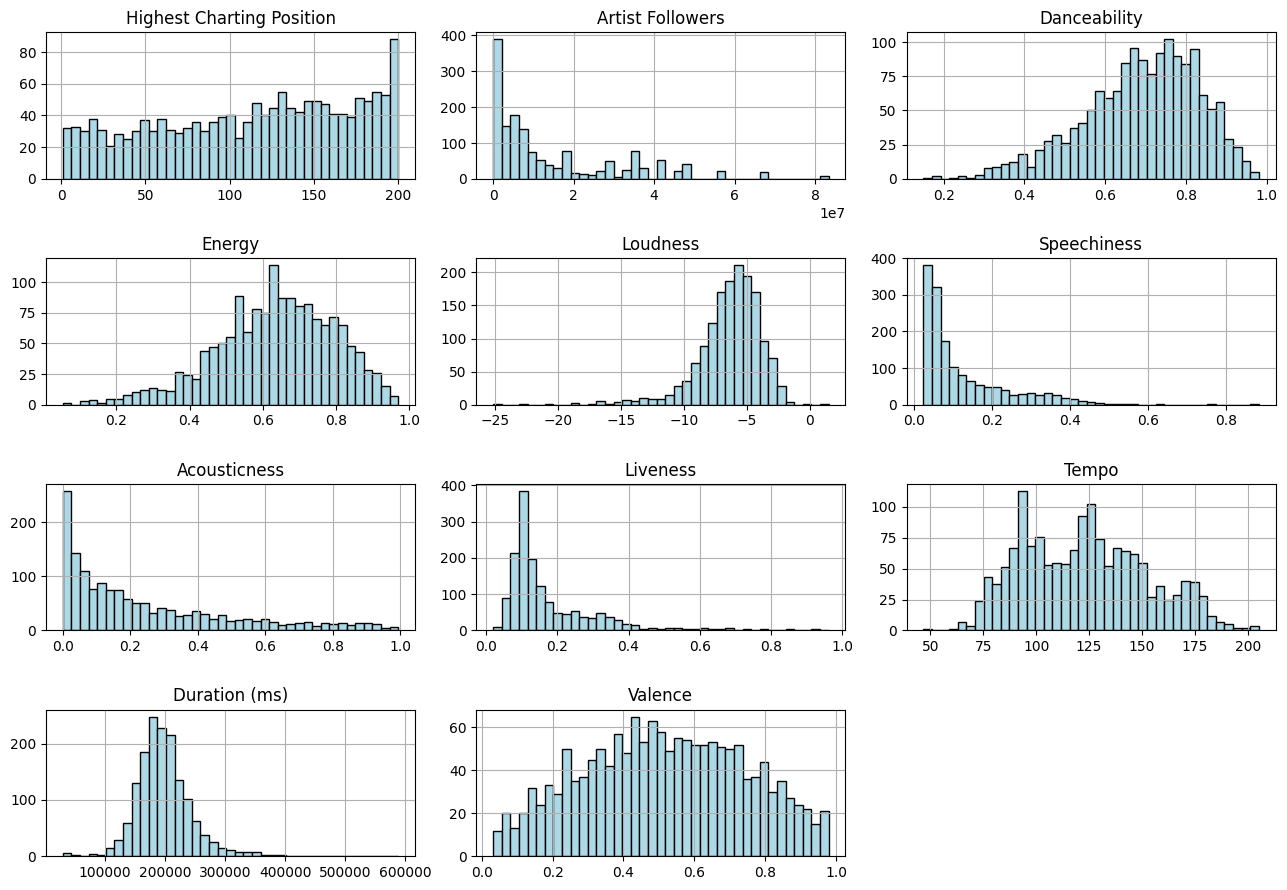

In [ ]:
n = int(1556**(1/2)) # bins

df_clean.hist(figsize=(13,9), bins=n, color='lightblue', edgecolor='black')

plt.tight_layout()
plt.show()

##Processing

In [ ]:
X = df_clean.drop(target, axis = 1)
y = df_clean[target]

In [ ]:
X.columns

Index(['Artist Followers', 'Danceability', 'Energy', 'Loudness', 'Speechiness',
       'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence'],
      dtype='object')

###Decision Tree Regression

In [ ]:
numLoops = 100 #Arbitrarily choose how many times to run?

rms_error = np.zeros(numLoops) #Stores the RMSE score from each loop.

for idx in range(0,numLoops): #Repeats 500 times.
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=3) # Arbitrarily choosing max_depth of 3
  model.fit(X_train,y_train) #Uses the products from X_train and the correct answers in y_train to learn patterns.
  y_pred = model.predict(X_test) #Makes prediction
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)}") #Average of RMSE values from loop.

CV RMSE: 57.05


####How do we choose the tree depth?

In [ ]:
max_depths = [1,2,3,4,5,6,7,8,9,10] #Runs different max depths
rms_depth = np.zeros(len(max_depths)) #Ang RMSE for depth
std_depth = np.zeros(len(max_depths)) #Consistency

numLoops = 100

for n, depth in enumerate(max_depths):
  rms_error = np.zeros(numLoops)

  for idx in range(0,numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

  rms_depth[n] = rms_error.mean()
  std_depth[n] = rms_error.std(ddof = 1)

In [ ]:
results = pd.DataFrame({
  'Max Depth': max_depths,
  'Mean RSME': rms_depth,
  'Std RMSE': std_depth
})

results

,Max Depth,Mean RSME,Std RMSE
0,1,56.630467,1.526422
1,2,56.672370,1.547098
2,3,56.886126,1.523887
3,4,57.321012,1.874500
4,5,58.360276,1.889810
5,6,59.349182,2.080664
6,7,60.768274,2.134485
7,8,62.833945,2.584229
8,9,64.668519,2.847056
9,10,66.556537,3.091500


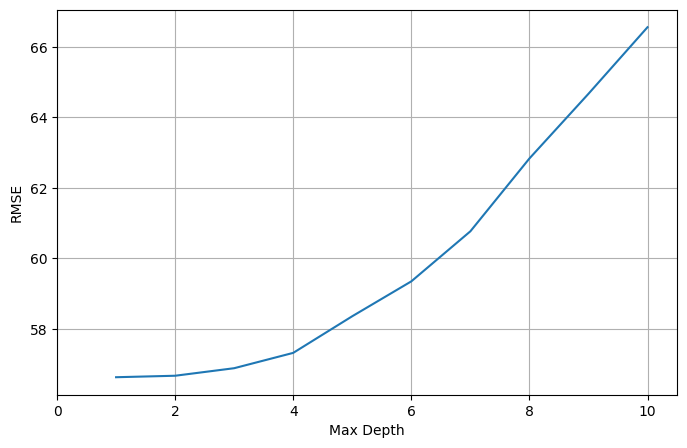

In [ ]:
#Plot result
plt.figure(figsize = (8,5))
plt.plot(max_depths, rms_depth)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.xlim(0, 10.5)
plt.grid()

In [ ]:
#Re run with max depth = 4
numLoops = 100

rms_error = np.zeros(numLoops)

for idx in range(0, numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  model = DecisionTreeRegressor(max_depth=4)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)}")

CV RMSE: 57.31


####Visualize the Decision Tree

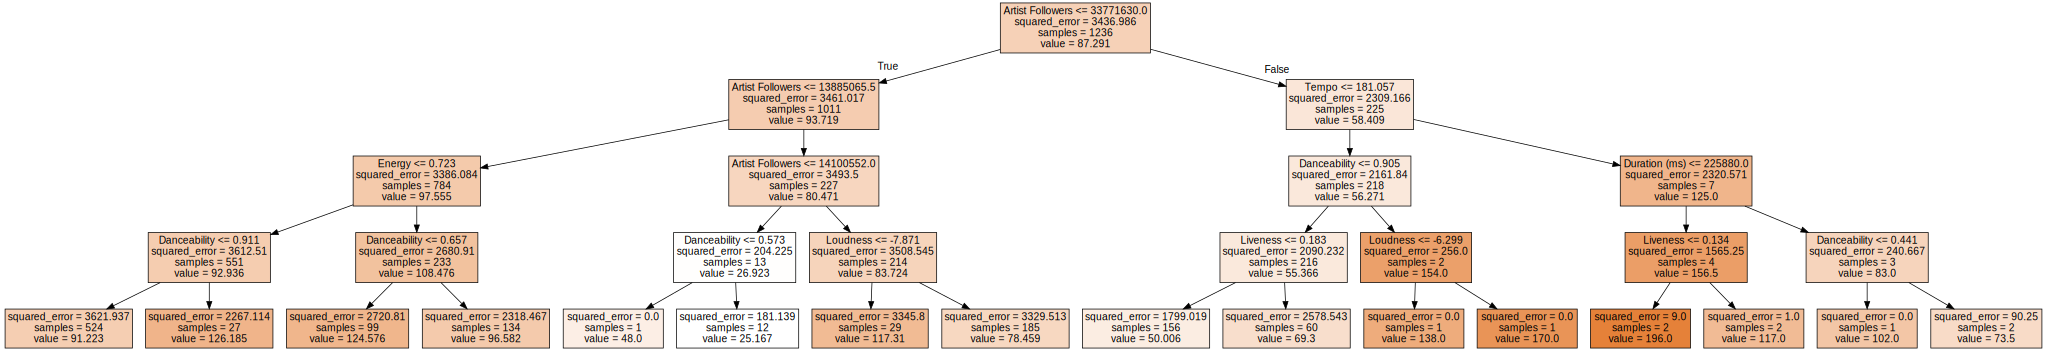

In [ ]:
#Readable view
display(
  graphviz.Source(
    tree.export_graphviz(
      model,
      feature_names = X.columns,
      filled = True,
    )
  )
)

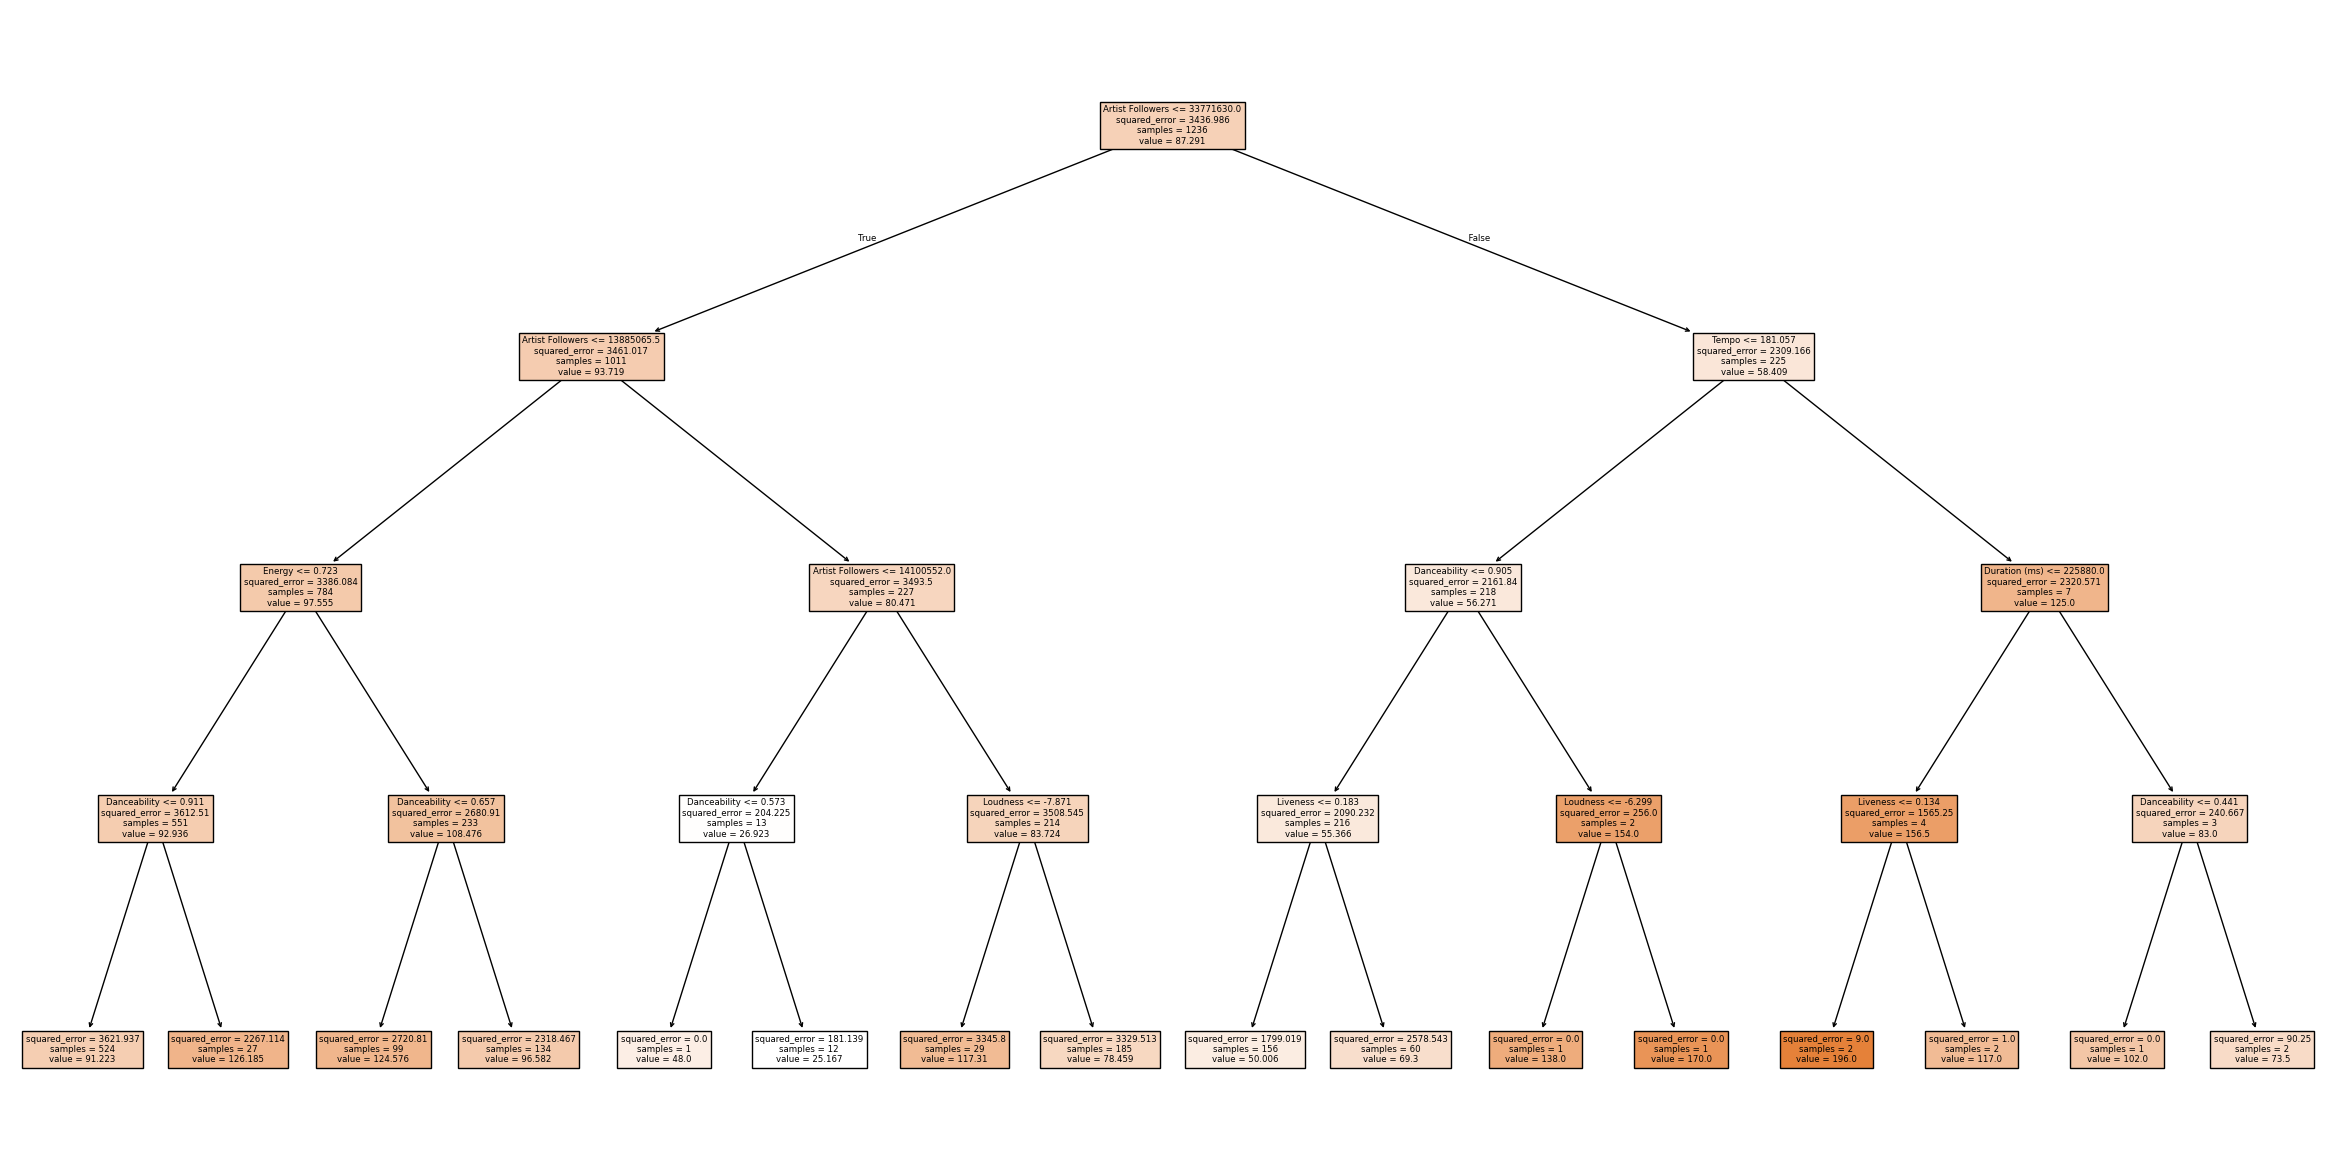

In [ ]:
#Full view
plt.figure(figsize=(30,15))
tree_plot = tree.plot_tree(
  model,
  feature_names = X.columns,
  filled=True,
)

###Random Forest

In [ ]:
#This line intentionally left blank
numLoops = 100

mean_error = np.zeros(numLoops)

np.random.seed(42)
for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=4, random_state=0)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  mean_error[idx] = mean_squared_error(y_test, y_pred)

print(f'RMSE: {np.sqrt(mean_error).mean()}')
print(f'RMSE_std: {np.sqrt(mean_error).std()}')

RMSE: 57.514749891674164
RMSE_std: 1.7915027426731325


In [ ]:
#Two parameters - n_estimators (number of trees), max_depth (number of splits)
numLoops = 100

mean_error = np.zeros(numLoops)

# np.random.seed(42)
for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
  model = RandomForestRegressor(n_estimators = 10) # n_estimators is number of trees in forest. Note: you can also choose max_depth for RFs
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  mean_error[idx] = mean_squared_error(y_test, y_pred)

print(f'RMSE: {np.sqrt(mean_error).mean()}')
print(f'RMSE_std: {np.sqrt(mean_error).std()}')
np.sqrt(mean_error)[:50]

RMSE: 58.94594735425189
RMSE_std: 1.5552759803535292


array([58.53571164, 56.13169403, 60.51595044, 57.45292258, 58.24222465,
       59.99923711, 60.40877306, 56.69058451, 58.67921366, 60.97582035,
       58.41836695, 58.7412477 , 59.93907386, 58.70740574, 57.53083783,
       57.71444375, 59.90247288, 59.62774865, 59.19129383, 61.92500108,
       55.79640259, 59.95261105, 58.78135714, 57.05311272, 60.81680547,
       58.68649198, 56.99432357, 60.84824263, 58.55018863, 56.56883461,
       59.3156539 , 59.37191275, 59.02332328, 58.48055384, 58.35355169,
       59.24775548, 57.26875316, 58.31294608, 55.86001247, 57.83291376,
       60.00746537, 59.60987942, 58.96878329, 59.73621292, 58.81625183,
       58.35608431, 62.36151737, 60.42814478, 60.5299736 , 59.17517664])

####How do you choose number of trees?

In [ ]:
num_trees = range(10,60,10)
cv_loops = 100
rmse_results = np.zeros(len(num_trees))
std_results = np.zeros(len(num_trees))

for n, trees in enumerate(num_trees):
  rmse_cv = np.zeros(cv_loops)
  np.random.seed(42)
  for i in range(cv_loops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)
    rfModel = RandomForestRegressor(n_estimators=trees)
    rfModel.fit(X_train, y_train)
    y_pred_rf = rfModel.predict(X_test)
    rmse_cv[i] = np.sqrt(mean_squared_error(y_test, y_pred_rf))

  print(trees,' trees finished.')
  rmse_results[n] = rmse_cv.mean()
  std_results[n] = rmse_cv.std()

10  trees finished.
20  trees finished.
30  trees finished.
40  trees finished.
50  trees finished.


In [ ]:
pickle.dump(rfModel, open('rfModel.p','wb'))

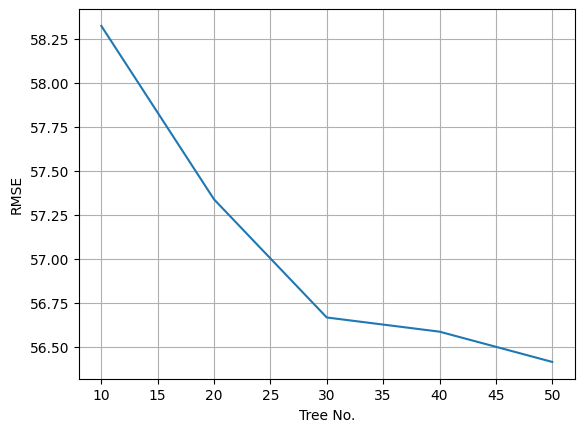

In [ ]:
plt.plot(num_trees, rmse_results)
plt.xlabel('Tree No.')
plt.ylabel('RMSE')
plt.grid()

In [ ]:
pd.DataFrame(zip(num_trees, rmse_results, std_results), columns='depth RMSE STDev'.split())

,depth,RMSE,STDev
0,10,58.321588,1.685231
1,20,57.336224,1.597398
2,30,56.665380,1.722025
3,40,56.584808,1.561695
4,50,56.412928,1.571541


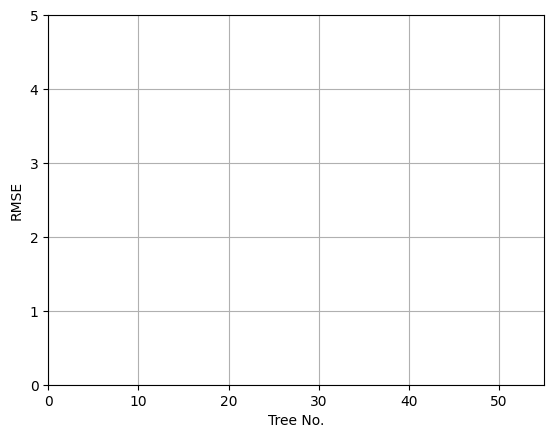

In [ ]:
# plt.errorbar(num_trees, rmse_results, yerr=(std_results*2,std_results*2))
plt.errorbar(num_trees, rmse_results, yerr=std_results)
plt.xlabel('Tree No.')
plt.ylabel('RMSE')
plt.ylim(0,5)
plt.xlim(0,55)
plt.grid()

In [ ]:
print(f'RMSE with 30 trees: {rmse_results[2]}')

RMSE with 30 trees: 56.66538034255696


In [ ]:
len(rfModel.estimators_)

50

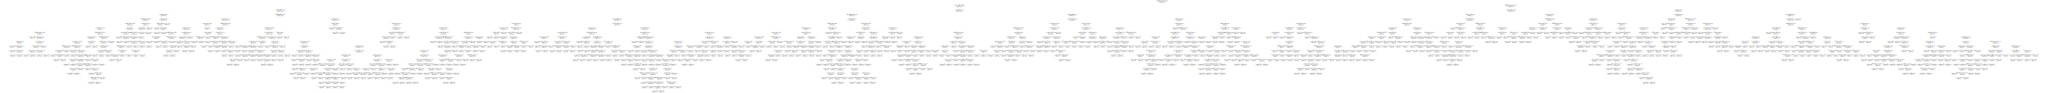

In [ ]:
#Display one tree from the random forest
display(
  graphviz.Source(
    tree.export_graphviz(
      rfModel.estimators_[0],
      feature_names = X.columns,
    )
  )
)

####Find Important Predictors

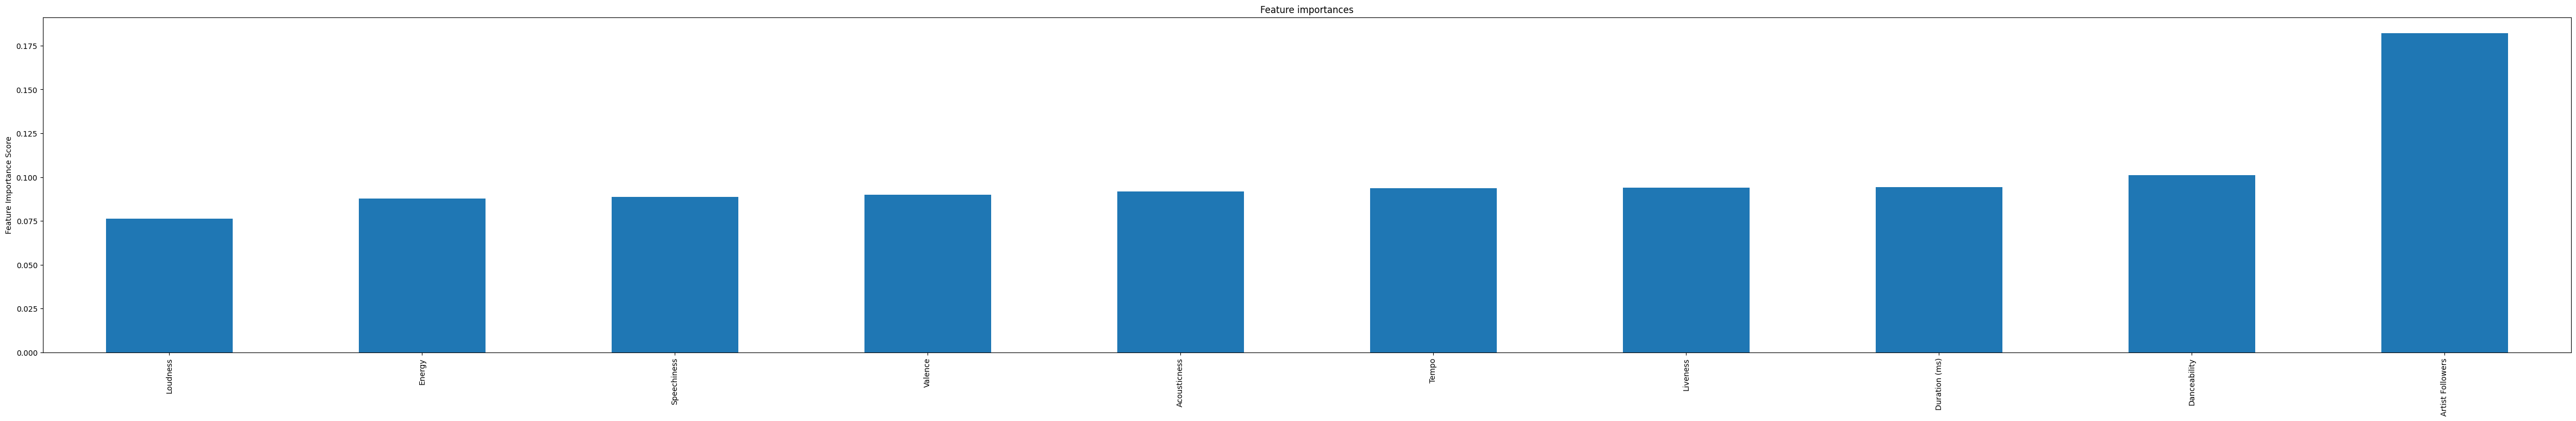

In [ ]:
importances = rfModel.feature_importances_
forest_importances = pd.Series(importances, index = X.columns)

plt.figure(figsize=(60,8))
# forest_importances.plot.bar()
forest_importances.sort_values(ascending=True).plot.bar()
plt.title("Feature importances")
plt.ylabel('Feature Importance Score');

In [ ]:
(forest_importances.sort_values(ascending=False) * 100).cumsum()

,0
Artist Followers,18.211648
Danceability,28.323878
Duration (ms),37.760918
Liveness,47.159960
Tempo,56.536603
Acousticness,65.727811
Valence,74.722961
Speechiness,83.597661
Energy,92.373937
Loudness,100.000000


###XGBoost

In [ ]:
X_train.columns.to_list()

['Artist Followers',
 'Danceability',
 'Energy',
 'Loudness',
 'Speechiness',
 'Acousticness',
 'Liveness',
 'Tempo',
 'Duration (ms)',
 'Valence']

In [ ]:
numLoops = 100
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.15)
  xgbr = xgb.XGBRegressor(objective ='reg:squarederror', verbosity=0, seed = 10)
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')

RMSE: 59.91807984624503


In [ ]:
y_pred_xgb[0]

np.float32(139.78204)

In [ ]:
y_test.to_numpy()[0]

np.int64(114)

In [ ]:
my_house = X_test[:3]
my_house

,Artist Followers,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence
1047,6852509,0.645,0.640,-6.871,0.1790,0.3950,0.286,140.248,48000,0.674
1481,862965,0.933,0.448,-4.491,0.1360,0.0253,0.104,103.981,167350,0.737
1203,56327031,0.749,0.792,-4.151,0.0826,0.2920,0.109,144.064,180000,0.239


In [ ]:
xgbr.predict(my_house)

array([139.78204 ,  55.76448 ,  75.936905], dtype=float32)

In [ ]:
y_test[:3]

,Highest Charting Position
1047,114
1481,187
1203,73


####XGBoost with Parameters

In [ ]:
#Specify the parameters you want to try and their ranges.
param_test = {
 'max_depth'     : [3, 4, 5, 6, 7],
 'learning_rate' : [0.1, 0.2, 0.3, 0.4],
 'n_estimators'  : [20, 40, 60, 80, 100, 120, 140]
}

#Perform the grid search
#This is the Cross Validation (140)
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor(objective = 'reg:squarederror', seed = 10),
    param_grid = param_test,
    scoring = 'neg_mean_squared_error',
    cv = 5,
)

#Fit to training data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.05, random_state = 42)
model = gsearch.fit(X_train,y_train)

#See grid search results
print(model.best_params_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 20}


Now we will fit our XGBoost model with the best parameters

In [ ]:
params = model.best_params_

numLoops = 100
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15)
  xgbr = xgb.XGBRegressor(
      objective ='reg:squarederror',
      verbosity=0,
      #Unpack a dictionary (* to unpack a list)
      **params,
      # learning_rate = 0.2,
      # max_depth = 3,
      # n_estimators = 100,
      seed = 10 #To be reproducable
  )
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean().round(2)}')

RMSE: 55.77


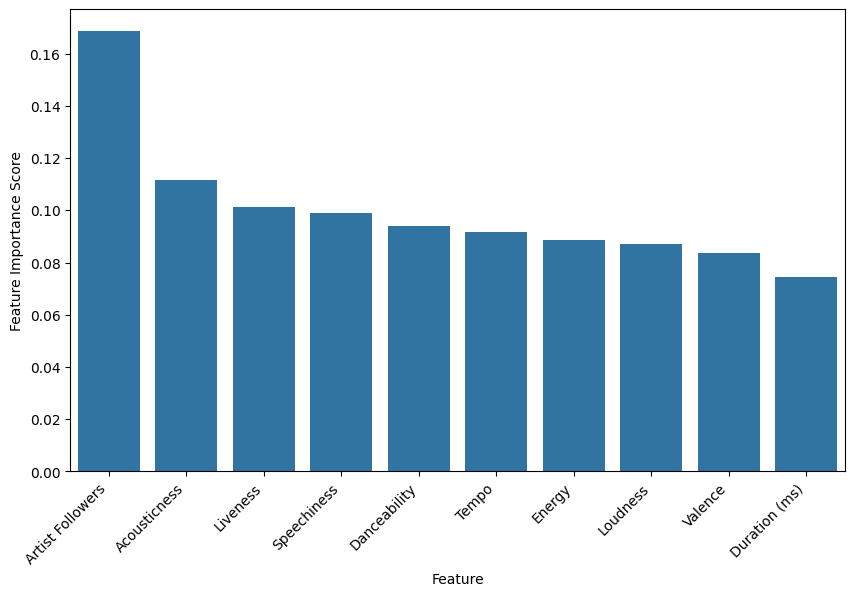

In [ ]:
feat_imp = pd.Series(xgbr.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize = (10,6))
sns.barplot(x = feat_imp.index, y = feat_imp.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Feature Importance Score');

In [ ]:
(feat_imp.sort_values(ascending=False)).cumsum()

,0
Artist Followers,0.168541
Acousticness,0.280000
Liveness,0.381311
Speechiness,0.480345
Danceability,0.574315
Tempo,0.666063
Energy,0.754680
Loudness,0.841617
Valence,0.925358
Duration (ms),1.000000


##Conclusion and Future Work

Changes
- Cleaned up notebook


Conclusions
- XGBoost w/best parameters
  - Streams RMSE: 3288715.48
  - Highest Charting Position RMSE: 55.77

Future Work
- Add comments
- Pick one target and save data_clean to HF